# Retail Sales Data — Complete Exploratory Data Analysis (EDA)

## Oasis Infobyte Internship
### Task 1 — EDA on Retail Sales Data

**Name:**   Mehwish Iqbal 

**Task:** Task 1



## Objective
Perform a thorough exploratory data analysis on the retail sales dataset to uncover sales trends, customer behaviour, product performance, and actionable business insights.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

### Dataset
This project uses the supplied retail sales dataset. It contains order-level information including:
- Order and customer details
- Date, region, and city
- Product category and product name
- Quantity, unit price, discount, sales, and profit
- Shipping cost and delivery time
- Payment method and customer satisfaction
- Return flag and order status

### Analysis Checklist
- Initial inspection: shape, dtypes, null values, duplicates
- Descriptive statistics: mean, median, mode, standard deviation
- Monthly and quarterly sales trends
- Customer age-group and gender analysis
- Top 10 best-selling products
- Revenue by product category
- Correlation heatmap
- Additional business visualizations
- Written observations after charts
- Actionable recommendations


## 1. Import Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




## 2. Load Dataset

In [71]:
# load file

df = pd.read_csv("retail_sales_dataset (1).csv")

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.00,Other,Central,Raipur,Groceries,Sugar,8.00,346.32,NaN,"4,043.14",289.18,56.04,Debit Card,NaN,True,Returned,7.00
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.00,Male,West,Mumbai,Beauty,Sunscreen,8.00,858.66,0.08,"9,147.31","5,355.56",64.49,Debit Card,5.00,False,Delivered,2.00
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.00,Other,West,Surat,Furniture,Sofa,4.00,"25,941.32",0.14,"110,156.97","36,956.51",67.65,Debit Card,4.00,False,Delivered,5.00
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.00,Other,West,Ahmedabad,Furniture,Bed Frame,9.00,"22,071.92",0.17,"262,066.11","66,644.99",54.47,EMI,3.00,False,Delivered,4.00
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.00,Male,Central,Nagpur,Groceries,Cooking Oil,1.00,320.06,0.31,323.95,31.38,48.81,Net Banking,4.00,False,Pending,4.00


## 3. Initial Data Inspection

We inspect the size, columns, data types, missing values, and duplicate records before cleaning.


In [72]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Information:")
df.info()


Shape: (4310, 21)

Columns:
['order_id', 'order_date', 'customer_id', 'customer_name', 'age', 'gender', 'region', 'city', 'product_category', 'product_name', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit', 'shipping_cost', 'payment_method', 'customer_satisfaction', 'return_flag', 'order_status', 'days_to_ship']

Data Types:
order_id                  object
order_date                object
customer_id               object
customer_name             object
age                      float64
gender                    object
region                    object
city                      object
product_category          object
product_name              object
quantity                 float64
unit_price               float64
discount_pct             float64
sales_amount             float64
profit                   float64
shipping_cost            float64
payment_method            object
customer_satisfaction    float64
return_flag               object
order_status              o

### Observation

The dataset contains **4,310 rows and 21 columns**. It includes product-level information, so the assignment's Top 10 best-selling products analysis can be performed directly.

There are missing values in several fields and **109 exact duplicate rows**. The next step is therefore data cleaning before calculating business metrics.


## 4. Data Cleaning

Cleaning decisions:
1. Convert `order_date` to datetime.
2. Convert numeric columns to numeric format.
3. Remove exact duplicate rows.
4. Remove records missing essential transaction identifiers (`order_id` or `order_date`).
5. Keep non-essential missing values for now and handle them appropriately in individual analyses.

We do **not** blindly replace every missing value with zero because that could distort sales, profit, satisfaction, or shipping metrics.


In [73]:
# Work on a copy
df = df.copy()

# Convert date
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Convert numeric columns
numeric_cols = [
    "age", "quantity", "unit_price", "discount_pct",
    "sales_amount", "profit", "shipping_cost",
    "customer_satisfaction", "days_to_ship"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove exact duplicate rows
before_duplicates = len(df)
df = df.drop_duplicates().copy()
removed_duplicates = before_duplicates - len(df)

# Remove rows without essential transaction ID/date
before_essential = len(df)
df = df.dropna(subset=["order_id", "order_date"]).copy()
removed_essential = before_essential - len(df)

print("Duplicates removed:", removed_duplicates)
print("Rows removed due to missing order_id/order_date:", removed_essential)
print("Cleaned shape:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum().sort_values(ascending=False))


Duplicates removed: 109
Rows removed due to missing order_id/order_date: 268
Cleaned shape: (3933, 21)

Remaining missing values:
customer_satisfaction    326
discount_pct             128
age                      116
quantity                 105
days_to_ship              86
gender                     0
region                     0
city                       0
product_category           0
product_name               0
order_date                 0
unit_price                 0
customer_name              0
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_id                0
return_flag                0
order_status               0
order_id                   0
dtype: int64


### Cleaning Observation

After removing exact duplicates and records without an order ID/date, the dataset is ready for analysis. Remaining missing values are concentrated in fields such as customer satisfaction, discount, age, quantity, and shipping time.

These fields will be handled according to the analysis rather than using one blanket imputation rule.


## 5. Feature Engineering

We create:
- `month` for monthly sales
- `quarter` for quarterly sales
- `year`
- `age_group` for demographic analysis


In [74]:
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["quarter"] = df["order_date"].dt.to_period("Q").astype(str)
df["year"] = df["order_date"].dt.year

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

df[["order_date","month","quarter","year","age","age_group"]].head()


,order_date,month,quarter,year,age,age_group
0,2024-08-15,2024-08,2024Q3,2024,39.00,36-45
1,2022-08-16,2022-08,2022Q3,2022,28.00,26-35
2,2021-08-29,2021-08,2021Q3,2021,41.00,36-45
3,2022-07-05,2022-07,2022Q3,2022,29.00,26-35
4,2020-05-07,2020-05,2020Q2,2020,9.00,18-25


## 6. Descriptive Statistics

The task requires mean, median, mode, and standard deviation for all numerical variables.


In [75]:
# Numerical columns requested for descriptive statistics
numeric_cols = [
    "age", "quantity", "unit_price", "discount_pct",
    "sales_amount", "profit", "shipping_cost",
    "customer_satisfaction", "days_to_ship"
]

mean_values = df[numeric_cols].mean()
median_values = df[numeric_cols].median()
mode_values = df[numeric_cols].mode().iloc[0]
std_values = df[numeric_cols].std()

descriptive_stats = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Standard Deviation": std_values
})

descriptive_stats


,Mean,Median,Mode,Standard Deviation
age,35.23,34.00,35.00,33.63
quantity,7.54,5.00,9.00,45.47
unit_price,"10,691.52","2,273.90",103.75,"17,357.16"
discount_pct,0.20,0.21,0.37,0.12
sales_amount,"63,124.98","9,673.58","10,874.57","328,759.35"
profit,"11,879.44","3,146.80",6.89,"54,957.99"
shipping_cost,63.33,63.44,42.69,18.35
customer_satisfaction,3.00,3.00,4.00,1.41
days_to_ship,5.60,6.00,8.00,4.00


### Observation

The descriptive statistics show substantial variation in transaction-level sales and profit. Comparing mean and median is particularly useful for identifying skewed variables: a large gap suggests that a smaller number of unusually large or small transactions are affecting the average.

Customer satisfaction and shipping time are also important operational metrics because they can be analyzed alongside sales and returns.


## 7. Monthly Sales Trend

Monthly sales help identify seasonal patterns and high/low demand periods.


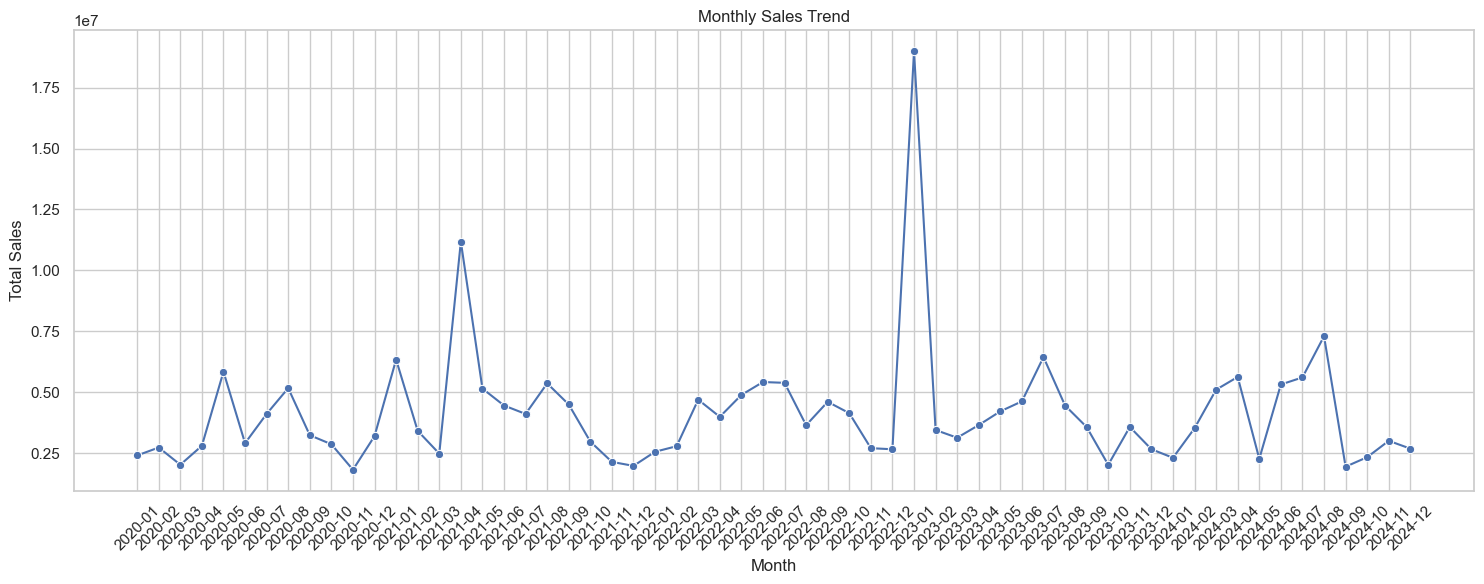

,month,sales_amount
0,2020-01,"2,401,884.13"
1,2020-02,"2,726,999.81"
2,2020-03,"2,020,868.86"
3,2020-04,"2,798,332.70"
4,2020-05,"5,839,235.97"
5,2020-06,"2,904,475.16"
6,2020-07,"4,107,821.74"
7,2020-08,"5,164,370.11"
8,2020-09,"3,232,399.97"
9,2020-10,"2,861,639.46"


In [76]:
monthly_sales = (
    df.groupby("month", as_index=False)["sales_amount"]
      .sum()
      .sort_values("month")
)

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x="month", y="sales_amount", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales


### Observation

The monthly trend shows noticeable fluctuations in sales across the dataset period. Peaks represent periods of stronger demand and should be considered when planning inventory and promotions.

Because this dataset spans multiple years, monthly comparisons should ideally also be reviewed year-over-year rather than assuming every month has identical demand conditions.


## 8. Quarterly Sales Trend

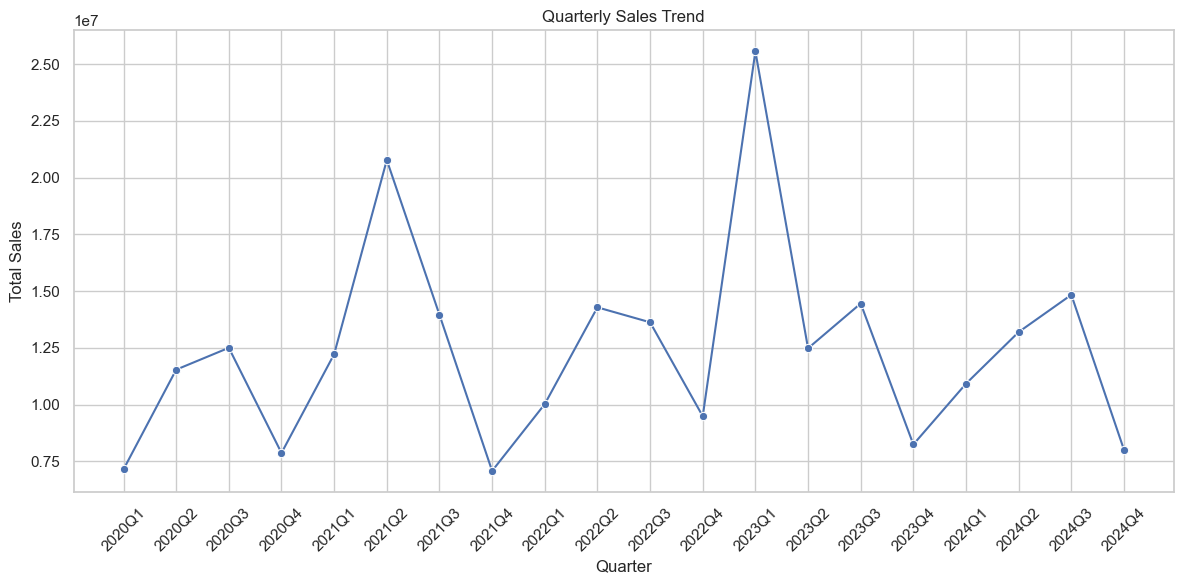

,quarter,sales_amount
0,2020Q1,"7,149,752.80"
1,2020Q2,"11,542,043.83"
2,2020Q3,"12,504,591.82"
3,2020Q4,"7,871,554.39"
4,2021Q1,"12,224,374.44"
5,2021Q2,"20,776,196.29"
6,2021Q3,"13,960,213.87"
7,2021Q4,"7,080,847.18"
8,2022Q1,"10,025,629.24"
9,2022Q2,"14,287,303.85"


In [77]:
quarterly_sales = (
    df.groupby("quarter", as_index=False)["sales_amount"]
      .sum()
      .sort_values("quarter")
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=quarterly_sales, x="quarter", y="sales_amount", marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

quarterly_sales


### Observation

Quarterly aggregation makes broader sales patterns easier to see than monthly data. Strong quarters can guide inventory and marketing planning, while weaker quarters should be investigated for changes in demand, discounts, product mix, or operational issues.


## 9. Customer Demographics — Age Group Distribution

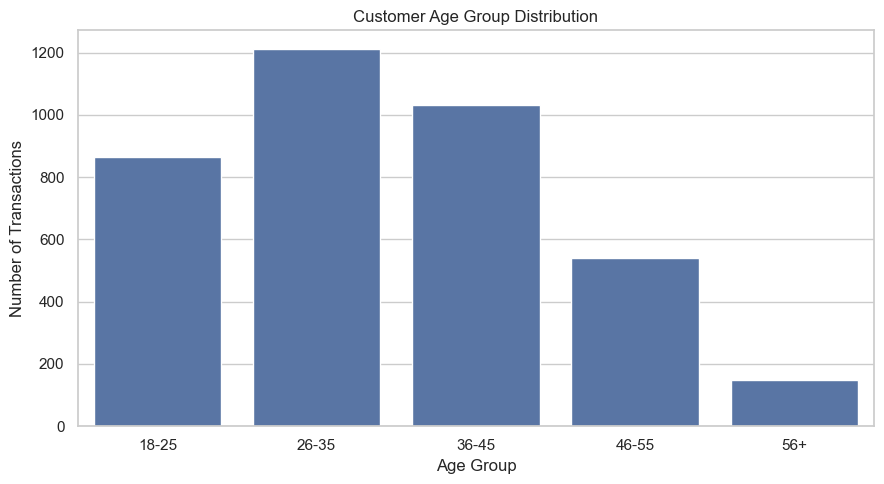

age_group
18-25     864
26-35    1211
36-45    1031
46-55     541
56+       147
Name: count, dtype: int64

In [78]:
age_counts = (
    df["age_group"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

age_counts


### Observation

The age-group chart shows how transaction activity is distributed across customer segments. This is useful for deciding which age groups deserve broader marketing reach and which may require more targeted offers.


## 10. Customer Demographics — Gender Breakdown

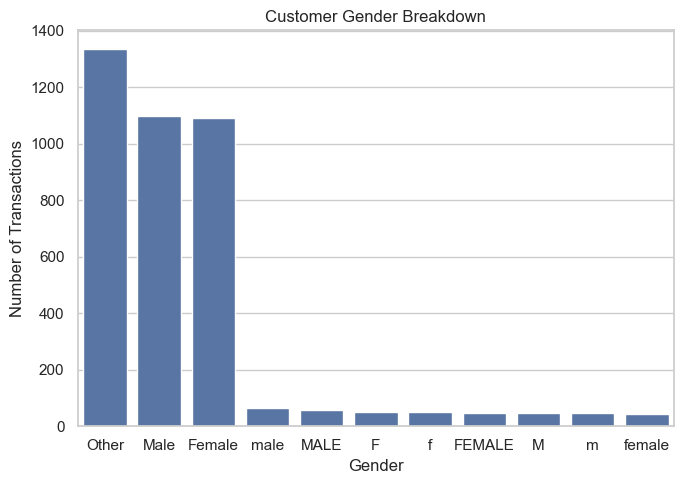

gender
Other     1335
Male      1100
Female    1090
male        65
MALE        58
F           51
f           50
FEMALE      48
M           46
m           46
female      44
Name: count, dtype: int64

In [79]:
gender_counts = df["gender"].value_counts(dropna=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_counts.index.astype(str), y=gender_counts.values)
plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

gender_counts


### Observation

The gender distribution provides a basic view of the customer mix. Gender should not be used alone for targeting; combining it with age, region, product category, and spending behaviour can produce more useful customer segments.


## 11. Top 10 Best-Selling Products

Here we rank products by total quantity sold.


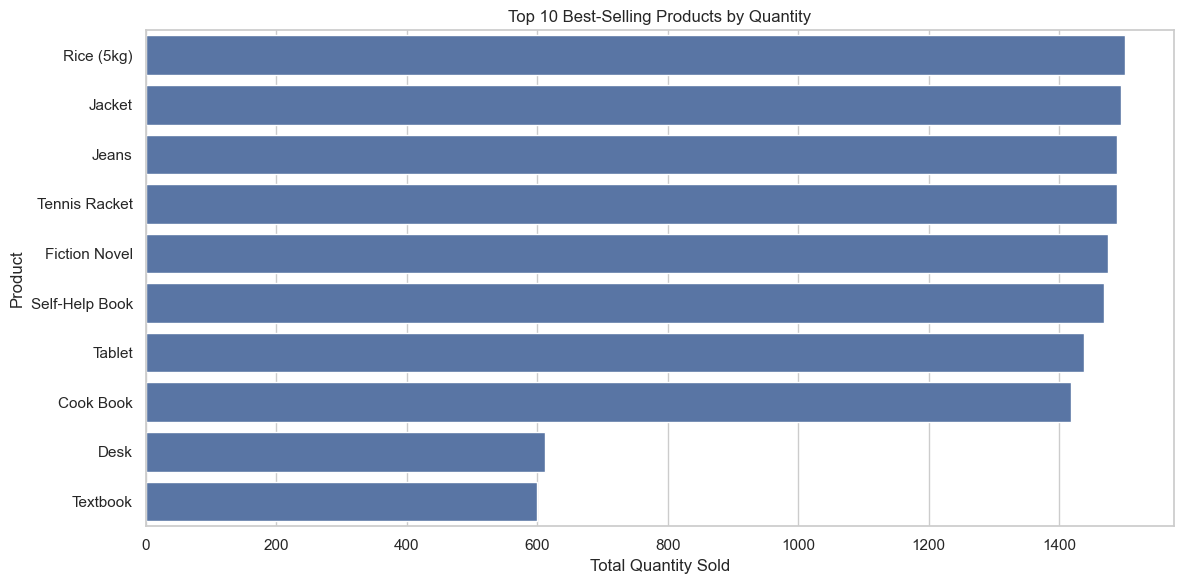

,product_name,quantity
0,Rice (5kg),"1,501.00"
1,Jacket,"1,495.00"
2,Jeans,"1,488.00"
3,Tennis Racket,"1,488.00"
4,Fiction Novel,"1,475.00"
5,Self-Help Book,"1,469.00"
6,Tablet,"1,438.00"
7,Cook Book,"1,418.00"
8,Desk,612.00
9,Textbook,600.00


In [80]:
top_10_products = (
    df.dropna(subset=["product_name", "quantity"])
      .groupby("product_name")["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_products,
    x="quantity",
    y="product_name"
)
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

top_10_products


### Observation

The Top 10 chart identifies the products with the highest sales volume. These products should receive close attention in inventory planning because stock-outs for high-volume products can directly affect sales.

For a stronger business decision, quantity should also be compared with product revenue and profit.


## 12. Revenue by Product Category

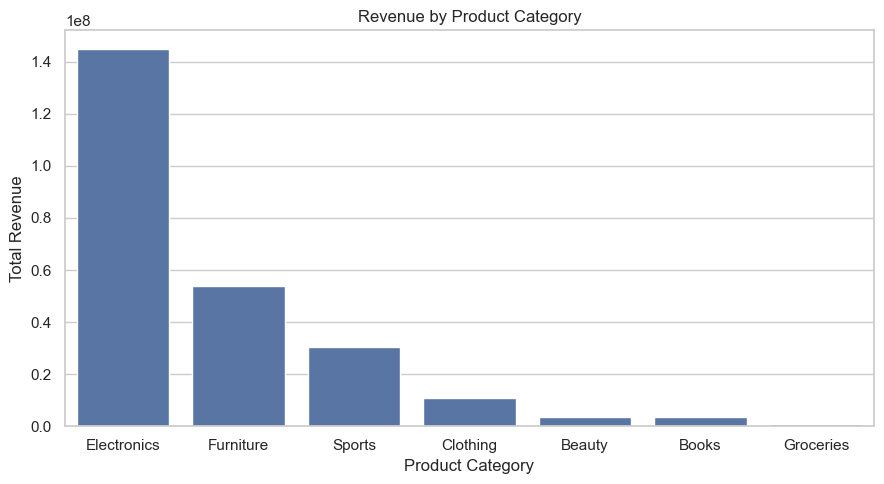

,product_category,sales_amount
0,Electronics,"144,842,413.15"
1,Furniture,"53,817,577.14"
2,Sports,"30,434,111.54"
3,Clothing,"11,010,564.36"
4,Beauty,"3,665,620.60"
5,Books,"3,552,511.04"
6,Groceries,"947,755.41"


In [81]:
category_revenue = (
    df.groupby("product_category")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=category_revenue,
    x="product_category",
    y="sales_amount"
)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

category_revenue


### Observation

Revenue differs across product categories, showing which parts of the product portfolio contribute most to total sales. Category revenue should be reviewed together with profit so that high-sales categories are not automatically assumed to be the most profitable.


## 13. Profit by Product Category

Revenue alone does not show business performance. We therefore compare total profit by category.


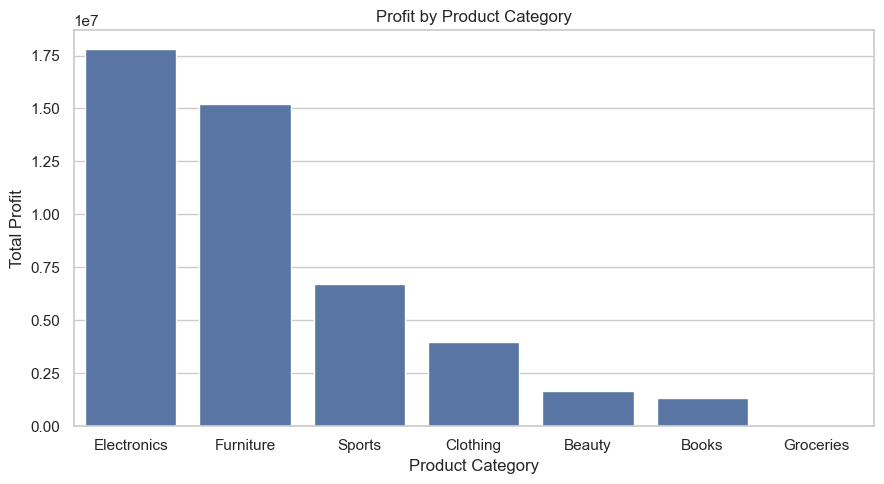

,product_category,profit
0,Electronics,"17,796,171.30"
1,Furniture,"15,210,712.69"
2,Sports,"6,713,176.69"
3,Clothing,"3,968,978.96"
4,Beauty,"1,642,331.20"
5,Books,"1,316,015.87"
6,Groceries,"74,452.32"


In [82]:
category_profit = (
    df.groupby("product_category")["profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=category_profit,
    x="product_category",
    y="profit"
)
plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

category_profit


### Observation

Comparing revenue with profit can reveal whether a category generates strong sales efficiently. Management should prioritize categories that combine healthy revenue with healthy profit rather than optimizing sales volume alone.


## 14. Correlation Heatmap

We examine correlations between numerical variables.


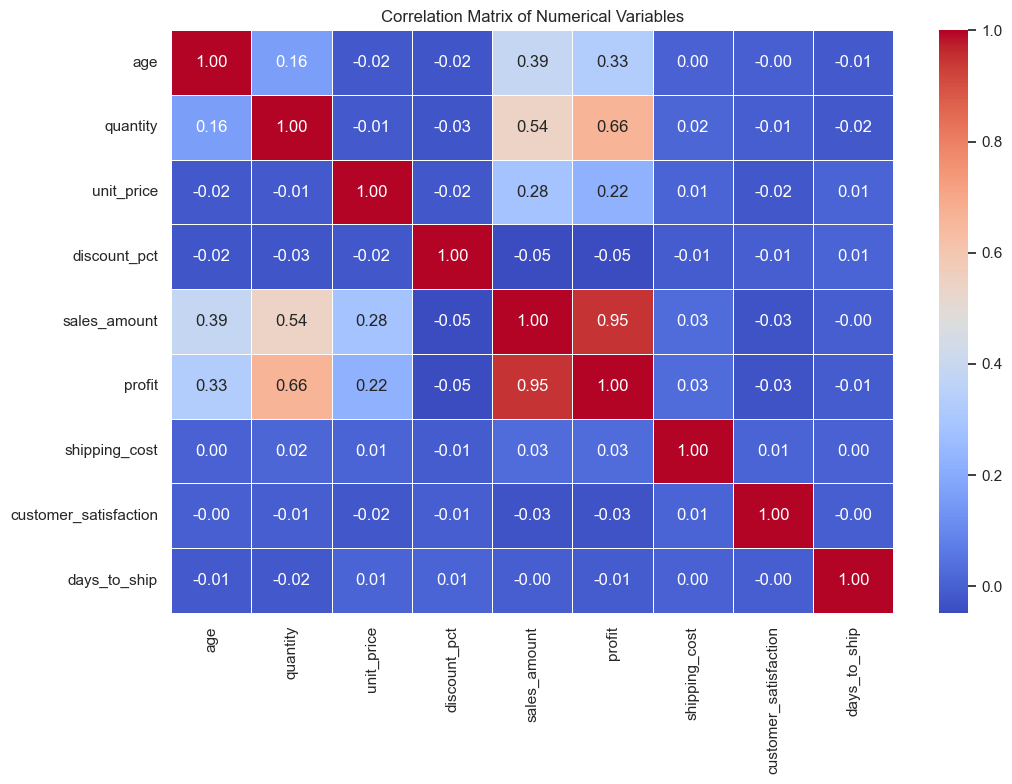

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
age,1.00,0.16,-0.02,-0.02,0.39,0.33,0.00,-0.00,-0.01
quantity,0.16,1.00,-0.01,-0.03,0.54,0.66,0.02,-0.01,-0.02
unit_price,-0.02,-0.01,1.00,-0.02,0.28,0.22,0.01,-0.02,0.01
discount_pct,-0.02,-0.03,-0.02,1.00,-0.05,-0.05,-0.01,-0.01,0.01
sales_amount,0.39,0.54,0.28,-0.05,1.00,0.95,0.03,-0.03,-0.00
profit,0.33,0.66,0.22,-0.05,0.95,1.00,0.03,-0.03,-0.01
shipping_cost,0.00,0.02,0.01,-0.01,0.03,0.03,1.00,0.01,0.00
customer_satisfaction,-0.00,-0.01,-0.02,-0.01,-0.03,-0.03,0.01,1.00,-0.00
days_to_ship,-0.01,-0.02,0.01,0.01,-0.00,-0.01,0.00,-0.00,1.00


In [83]:
corr_cols = [
    "age", "quantity", "unit_price", "discount_pct",
    "sales_amount", "profit", "shipping_cost",
    "customer_satisfaction", "days_to_ship"
]

correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

correlation_matrix


### Observation

The heatmap helps identify which numerical variables move together. Strong relationships between quantity, unit price, and sales amount are especially important because sales amount is mechanically related to transaction quantity and price.

Correlation does **not** prove that one variable causes another. Operational relationships should be investigated with additional analysis.


## 15. Additional Visualization — Return Rate by Product Category

A non-obvious business insight is whether some product categories have a higher return rate than others. This can reveal potential product-quality, expectation, or customer-experience issues.


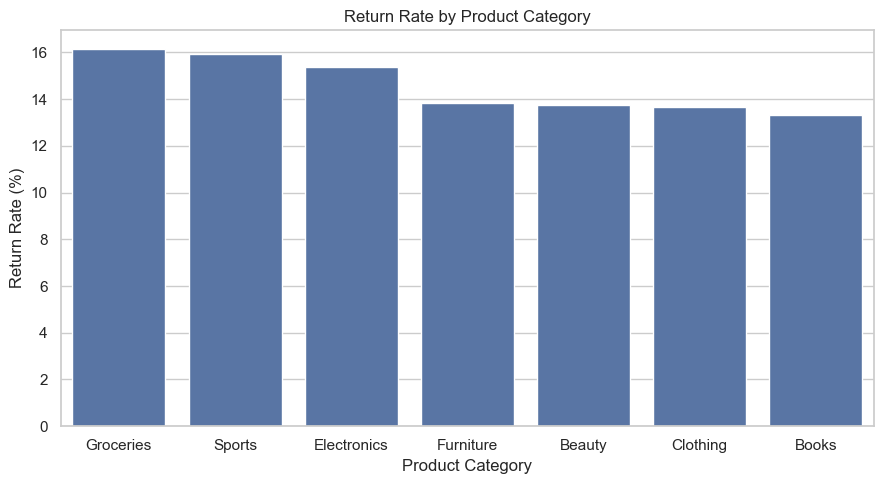

,product_category,return_rate_pct
0,Groceries,16.13
1,Sports,15.95
2,Electronics,15.37
3,Furniture,13.84
4,Beauty,13.73
5,Clothing,13.68
6,Books,13.32


In [84]:
# Normalize return flag to boolean-like values
return_bool = df["return_flag"].astype(str).str.strip().str.lower().map({
    "true": True,
    "false": False
})

return_rate = (
    pd.DataFrame({
        "product_category": df["product_category"],
        "returned": return_bool
    })
    .dropna(subset=["product_category", "returned"])
    .groupby("product_category")["returned"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="return_rate_pct")
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=return_rate,
    x="product_category",
    y="return_rate_pct"
)
plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.tight_layout()
plt.show()

return_rate


### Observation

Return rates can highlight operational problems that are not visible in sales totals. A category with strong revenue but a relatively high return rate may require investigation into product quality, descriptions, sizing/specifications, packaging, or customer expectations.

This makes return rate a useful KPI alongside revenue and profit.


## 16. Regional Sales Analysis

We compare total sales across regions to identify geographic differences.


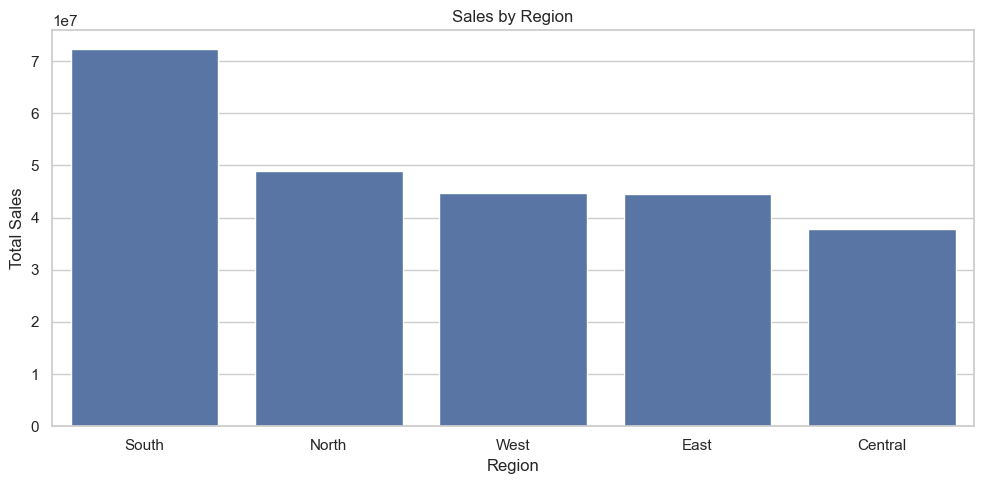

,region,sales_amount
0,South,"72,280,971.42"
1,North,"48,969,538.86"
2,West,"44,771,366.28"
3,East,"44,525,650.30"
4,Central,"37,723,026.38"


In [85]:
region_sales = (
    df.groupby("region")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=region_sales,
    x="region",
    y="sales_amount"
)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

region_sales


### Observation

Regional sales differences can help management decide where to focus marketing, inventory, and distribution resources. Lower-performing regions should be investigated before additional spending is committed.


## 17. Payment Method Analysis

Payment method usage can help understand customer purchasing preferences.


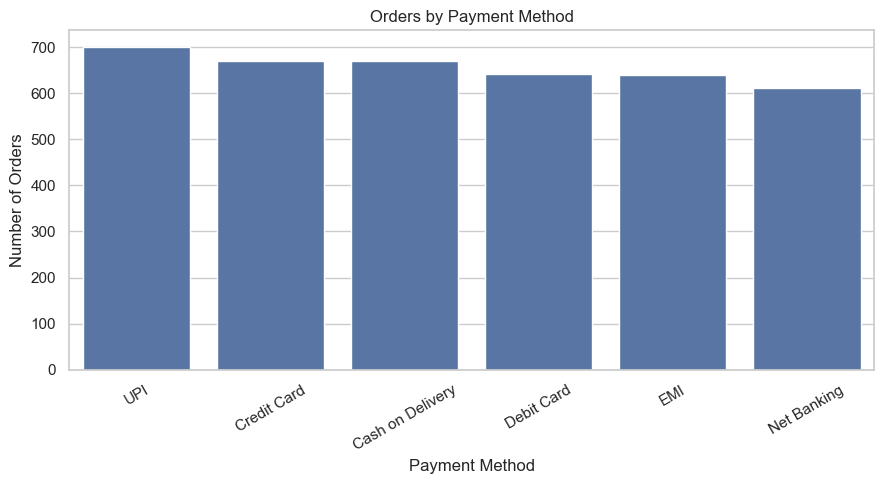

payment_method
UPI                 701
Credit Card         669
Cash on Delivery    669
Debit Card          642
EMI                 640
Net Banking         612
Name: count, dtype: int64

In [86]:
payment_counts = df["payment_method"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(
    x=payment_counts.index.astype(str),
    y=payment_counts.values
)
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

payment_counts


### Observation

Payment-method usage indicates which payment options customers use most frequently. Maintaining reliable support for the most-used methods can reduce checkout friction and improve the customer experience.


## 18. Order Status Analysis

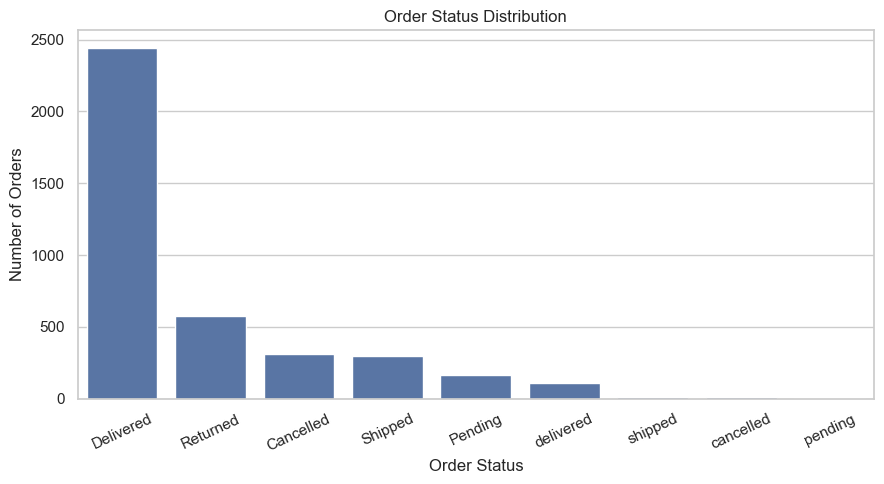

order_status
Delivered    2442
Returned      574
Cancelled     312
Shipped       295
Pending       168
delivered     110
shipped        15
cancelled      12
pending         5
Name: count, dtype: int64

In [87]:
status_counts = df["order_status"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(
    x=status_counts.index.astype(str),
    y=status_counts.values
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

status_counts


### Observation

Order status provides an operational view of the sales process. Delivered, pending, cancelled, and returned orders should be monitored separately because a high number of non-delivered orders can reduce realized revenue and customer satisfaction.


## 19. Customer Satisfaction by Product Category

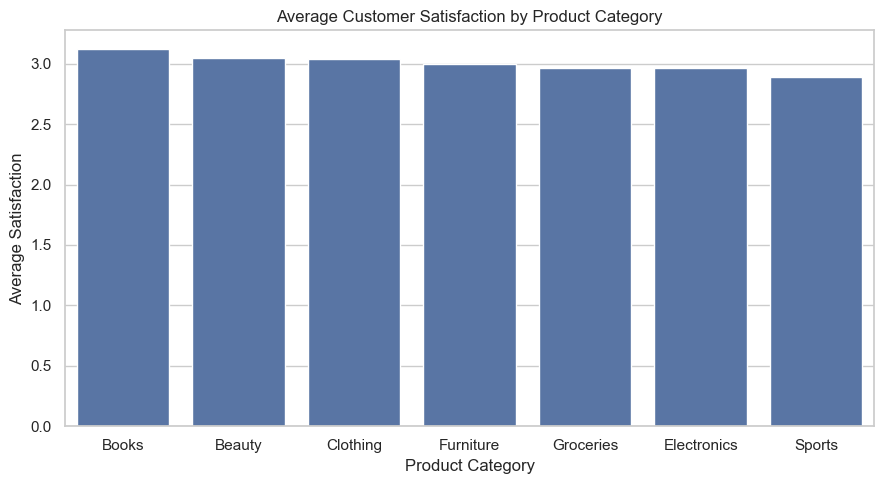

,product_category,customer_satisfaction
0,Books,3.12
1,Beauty,3.05
2,Clothing,3.04
3,Furniture,3.00
4,Groceries,2.97
5,Electronics,2.96
6,Sports,2.89


In [88]:
satisfaction_by_category = (
    df.groupby("product_category")["customer_satisfaction"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=satisfaction_by_category,
    x="product_category",
    y="customer_satisfaction"
)
plt.title("Average Customer Satisfaction by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Satisfaction")
plt.tight_layout()
plt.show()

satisfaction_by_category


### Observation

Customer satisfaction varies across product categories. Categories with lower satisfaction should be investigated alongside return rates, shipping times, discounts, and product-level feedback to identify the underlying causes.


## 20. Key Findings

The final findings should be based on the generated tables and charts rather than assumptions.

### Areas identified in this analysis
- Sales trends vary by month and quarter.
- The dataset supports genuine product-level Top 10 analysis.
- Revenue and profit should be analyzed together.
- Customer demographics provide useful segmentation variables.
- Return rate is an important additional KPI.
- Region and payment method reveal operational/customer behaviour patterns.
- Order status and shipping time provide operational context.
- Customer satisfaction can be compared with category performance.


## 21. Actionable Business Recommendations

### 1. Protect stock availability for top-selling products
Use the Top 10 product results to improve inventory planning and reduce stock-outs for high-volume products.

### 2. Optimize category strategy using both revenue and profit
Do not prioritize categories based on sales alone. Compare revenue, profit, quantity, and return rate before deciding inventory and promotional budgets.

### 3. Investigate high-return categories/products
For categories or products with elevated return rates, review product quality, product descriptions, packaging, specifications, and customer expectations.

### 4. Use regional sales for targeted planning
Allocate marketing, inventory, and distribution resources according to regional demand rather than using a uniform strategy everywhere.

### 5. Improve customer experience using operational KPIs
Monitor shipping time, order status, and customer satisfaction together. Long shipping times or high non-delivery/return rates may indicate areas where operational improvements can increase customer satisfaction.


## 22. Final Conclusion

This EDA provides a complete view of the supplied retail dataset from four perspectives: **sales performance, customer behaviour, product performance, and operations**.

The analysis identifies monthly and quarterly sales patterns, customer demographic trends, the Top 10 products, category revenue and profit, regional performance, return rates, payment preferences, order status, and customer satisfaction.

The most important business lesson is that sales alone are not enough to evaluate performance. A stronger retail strategy combines **revenue + profit + product demand + returns + customer satisfaction + operational performance**.

Future analysis can extend this project into an interactive Power BI dashboard or a more advanced customer/product profitability analysis.


**THANK YOU**